# Import Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

# Import Dataset

In [52]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [53]:
X_train.shape

(60000, 28, 28)

# Show Image

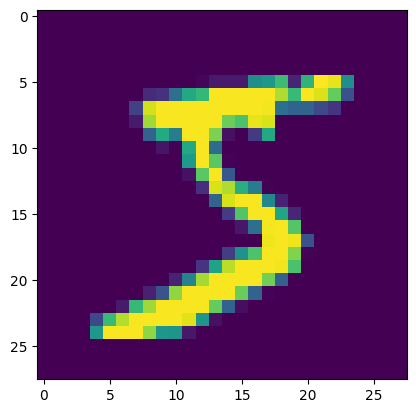

In [54]:
plt.imshow(X_train[0])

# Data Scalling

In [55]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Sequencial Model Build

```python
keras.layers.Flatten(data_format=None, **kwargs)
```

In [56]:
model = Sequential()

In [57]:
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

# Compile

In [58]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary

In [59]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [60]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8618 - loss: 0.4779 - val_accuracy: 0.9525 - val_loss: 0.1620
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9617 - loss: 0.1324 - val_accuracy: 0.9667 - val_loss: 0.1131
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9729 - loss: 0.0908 - val_accuracy: 0.9697 - val_loss: 0.0951
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9822 - loss: 0.0605 - val_accuracy: 0.9682 - val_loss: 0.1095
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9862 - loss: 0.0481 - val_accuracy: 0.9695 - val_loss: 0.1021
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9898 - loss: 0.0362 - val_accuracy: 0.9745 - val_loss: 0.0868
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9926 - loss: 0.0261 - val_accuracy: 0.9740 - val_loss: 0.0889
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9938 - loss: 0.0222 - 

# Model Predict

In [61]:
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

# Plot Test Data

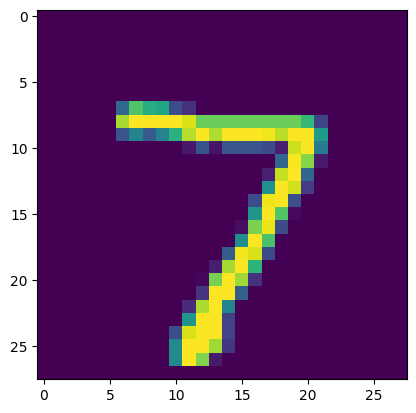

In [62]:
plt.imshow(X_test[0])

# Accuracy Check

In [63]:
accuracy_score(y_test, y_pred)

0.9745

# Plot Accuracy and Loss Graph

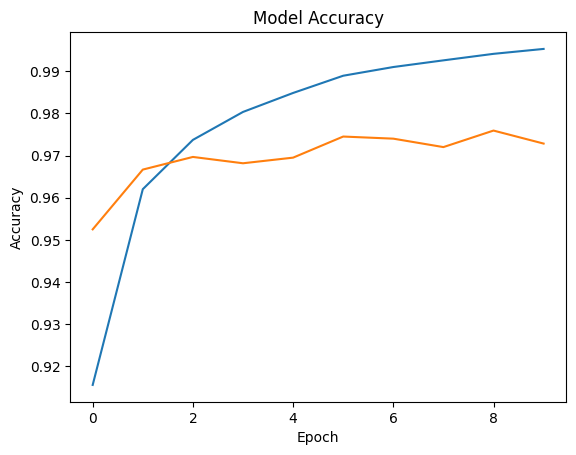

In [64]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

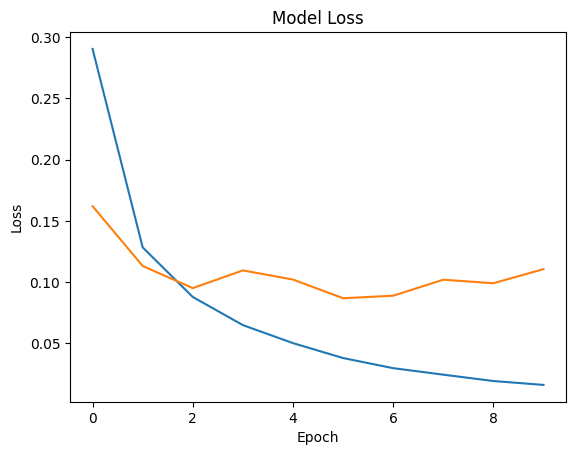

In [65]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

# Specific Data Prediction

In [66]:
model.predict(X_test[300].reshape(1, 28, 28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([4])

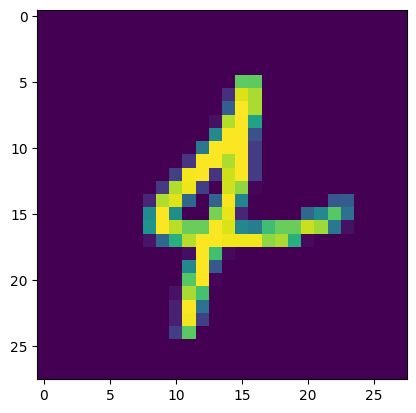

In [67]:
plt.imshow(X_test[300])